### Table Content
------------------

- [Introduction](#intro)
- [Import libraries and packages](#ilp)
- [Dataset Information](#di)
- [Separate 'Title' field and preprocess it](#preprocess)
    - [Removing unwanted charaters and words](#remv)
    - [Tokenization and word_index (vocabulary) ](#token)
    - [Convert titles into sequences and Make n_gram model](#ngram)
    - [Make all titles with same length and padding them](#pad)
- [Preprare features (X) and labels (Y)](#xy)
- [Architechture of Bidirectional LSTM neural network](#blstm)
- [Train Bi-LSTM neural network](#train)
- [Plotting accuracy and loss graph](#acc)
- [Predict new title (Testing)](#new)

----------------




<a name="ilp"></a>
# Import necessary libraries and packages 

In [1]:
import pandas as pd
import numpy as np
import string
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

FILE = './pg1513.txt'

OOV_TOKEN = '<oov>'

In [2]:
with open(FILE, 'r', encoding='utf-8') as file: text = file.read()

In [3]:
text = re.sub(r'\s+', ' ', re.sub(r'[^a-zA-Z,.;:!? ]+', '', text.replace('\n', ' '))).strip()

In [4]:
tokenizer = Tokenizer(oov_token=OOV_TOKEN) # For those words which are not found in word_index
#tokenizer.fit_on_texts(medium_data['title'])
lines = re.split(r".,", text)
tokenizer.fit_on_texts(lines)
total_words = len(tokenizer.word_index) + 1

print("Total number of words: ", total_words)
print("OOV: ", tokenizer.word_index[OOV_TOKEN])

input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total input sequences: ", len(input_sequences))

Total number of words:  4701
OOV:  1
Total input sequences:  26116


In [5]:
# pad sequences 
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
input_sequences[1]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2, 53, 51])

In [6]:
# create features and label
xs, labels = input_sequences[:,:-1],input_sequences[:,-1]
ys = tf.keras.utils.to_categorical(labels, num_classes=total_words)

In [7]:
print(xs[5])
print(labels[5])
print(ys[5][14])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   2  53  51 306   7  15]
3
0.0


In [8]:
model = Sequential()
#model.add(Bidirectional(LSTM(150)))
model.add(Embedding(total_words, 100))
model.add(LSTM(100,return_sequences=True))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['mse'])

In [9]:
history = model.fit(xs, ys, epochs=10, verbose=1)
print(model.summary())
print(model)

Epoch 1/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 144s 170ms/step - loss: 7.1844 - mse: 2.1177e-04
Epoch 2/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 137s 164ms/step - loss: 6.5884 - mse: 2.1120e-04
Epoch 3/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 137s 158ms/step - loss: 6.4359 - mse: 2.1075e-04
Epoch 4/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 128s 156ms/step - loss: 6.2538 - mse: 2.0967e-04
Epoch 5/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 129s 158ms/step - loss: 6.1029 - mse: 2.0894e-04
Epoch 6/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 126s 155ms/step - loss: 5.9432 - mse: 2.0781e-04
Epoch 7/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 128s 156ms/step - loss: 5.7549 - mse: 2.0682e-04
Epoch 8/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 128s 157ms/step - loss: 5.6360 - mse: 2.0593e-04
Epoch 9/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 165s 202ms/step - loss: 5.4821 - mse: 2.0505e-04
Epoch 10/10
817/817 ━━━━━━━━━━━━━━━━━━━━ 134s 164ms/step - loss: 5.3357 - mse: 2.0405e-04


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 133, 100)       │       470,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 133, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4701)           │       474,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,317,105 (12.65 MB)

 Trainable params: 1,105,701 (4.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,211,404 (8.44 MB)

None
<Sequential name=sequential, built=True>


<a name="acc"></a>
# Plotting model accuracy and loss

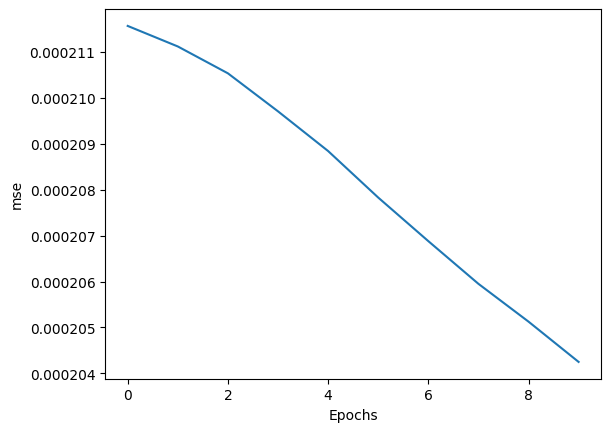

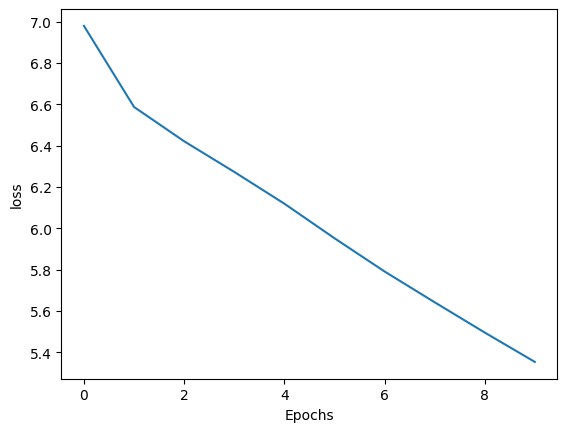

In [12]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.show()

plot_graphs(history, 'mse')
plot_graphs(history, 'loss')

<a name="new"></a>
# Predicting next word

In [15]:
seed_text = "But soft!"
next_words = 10

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predictions= model.predict(token_list, verbose=0)
    predicted  = np.argmax(predictions)
    output_word = tokenizer.index_word.get(predicted, "")
    seed_text += " " + output_word

print(seed_text)

But soft! a man is i am not is thou is not
